In [1]:
import numpy as np 
import pandas as pd 

In [2]:
apt_data = pd.read_csv('/kaggle/input/datasets/micahluftig/apt-and-p-data/apt_data.csv')
p_data = pd.read_csv('/kaggle/input/datasets/micahluftig/apt-and-p-data/p_data.csv')

In [3]:
print(apt_data.head())
print('\n\n\n' + '$#%^&*(' * 3 + '\n\n\n')
print(p_data.head())

                     intake_id animal_id          intake_time  \
0  a521520_2013-10-01_07:51:00   a521520  2013-10-01 07:51:00   
1  a664235_2013-10-01_08:33:00   a664235  2013-10-01 08:33:00   
2  a664236_2013-10-01_08:33:00   a664236  2013-10-01 08:33:00   
3  a664237_2013-10-01_08:33:00   a664237  2013-10-01 08:33:00   
4  a664233_2013-10-01_08:53:00   a664233  2013-10-01 08:53:00   

        discharge_time intake_type intake_reason outcome_category  \
0  2013-10-01 15:39:00       stray       routine          unknown   
1  2013-10-01 10:39:00       stray       routine            admin   
2  2013-10-01 10:44:00       stray       routine            admin   
3  2013-10-01 10:44:00       stray       routine            admin   
4  2013-10-01 15:33:00       stray       medical         deceased   

  outcome_subcategory  los_days  
0             unknown      0.32  
1             program      0.09  
2             program      0.09  
3             program      0.09  
4            behavior   

In [4]:
apt_data['intake_date'] = pd.to_datetime(apt_data['intake_time']).dt.date
daily_counts = apt_data.groupby('intake_date').size()

print(f"Mean daily intake: {daily_counts.mean():.2f}")
print(f"Variance: {daily_counts.var():.2f}")
print(f"Std dev: {daily_counts.std():.2f}")

Mean daily intake: 45.42
Variance: 321.88
Std dev: 17.94


count    122999.000000
mean         18.510455
std          43.244376
min           0.000000
25%           1.390000
50%           5.130000
75%          15.260000
max        1521.980000
Name: los_days, dtype: float64


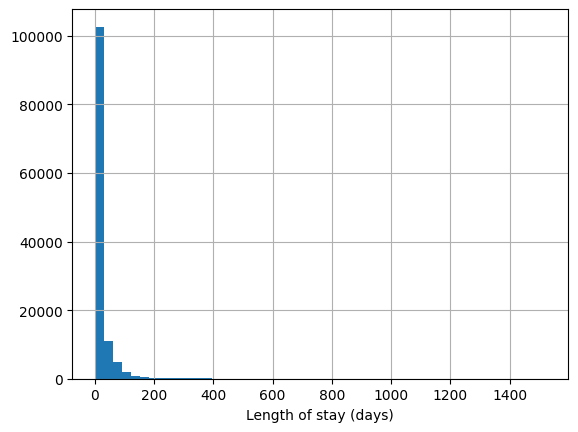

In [5]:
print(apt_data['los_days'].describe())

import matplotlib.pyplot as plt
apt_data['los_days'].hist(bins=50)
plt.xlabel('Length of stay (days)')
plt.show()

In [6]:
from scipy import stats
shape, loc, scale = stats.gamma.fit(apt_data['los_days'].dropna())

In [7]:
print(apt_data['los_days'].quantile([0.95, 0.99, 0.999]))
print((apt_data['los_days'] > 100).sum())

0.950     77.76000
0.990    191.78000
0.999    519.04362
Name: los_days, dtype: float64
3928


This isn't just outlier noise — it's a meaningful subpopulation
3,928 animals staying over 100 days is way too many to just be typos or rare edge cases. Combined with the jump from 191 days (99th percentile) to 519 days (99.9th percentile), this looks like there are genuinely two different populations in your data — normal-turnover animals (median ~5 days) and a distinct group of long-term/hard-to-place animals.

In [8]:
total = len(apt_data)
pct_long_stay = (apt_data['los_days'] > 100).sum() / total * 100
print(f"{pct_long_stay:.2f}% of animals stay over 100 days")

# What's different about them?
long_stay = apt_data[apt_data['los_days'] > 100]
print(long_stay[['intake_type', 'intake_reason', 'outcome_category']].describe(include='object'))

3.19% of animals stay over 100 days
       intake_type intake_reason outcome_category
count         3928          3928             3928
unique           6             4                4
top          stray       routine            alive
freq          2491          3344             3485


That's actually a pretty informative result — and it changes the story a bit from what I hypothesized.
What this tells you:

Not primarily a medical issue — "routine" intake reason dominates (3,344 of 3,928), not medical. So this isn't mostly sick/injured animals stuck in long-term care.
Not primarily a "stuck forever" outcome — 3,485 of 3,928 eventually go alive (presumably adopted/transferred out), not deceased or euthanized. So these are animals that do eventually leave — just very slowly.
Stray dominates intake_type (2,491 of 3,928) — consistent with the idea that these are likely harder-to-place strays (maybe less socialized, less "adoptable" breed/age profile, etc.) rather than owner surrenders with known medical needs.

So the story looks less like "distinct sick population" and more like: a long tail of harder-to-place-but-otherwise-healthy animals who eventually get adopted, just very slowly — which is arguably more relevant to your capacity simulation, not less. These are exactly the animals that quietly eat up kennel space for months while everyone assumes turnover is fast.

In [9]:
threshold = 100
short_stay = apt_data[apt_data['los_days'] <= threshold]['los_days']
long_stay = apt_data[apt_data['los_days'] > threshold]['los_days']

p_long_stay = len(long_stay) / len(apt_data)  # ~0.0319

# Fit each population separately
# shape_short, loc_short, scale_short = stats.gamma.fit(short_stay, floc=0)
# shape_long, loc_long, scale_long = stats.gamma.fit(long_stay, floc=threshold)

short_stay_clean = short_stay.replace(0, 0.001)
shape_short, loc_short, scale_short = stats.gamma.fit(short_stay_clean, floc=0)
shape_long, loc_long, scale_long = stats.gamma.fit(long_stay, floc=threshold)

In [10]:
# print(f"{499 / len(apt_data) * 100:.2f}% of records have los_days == 0")

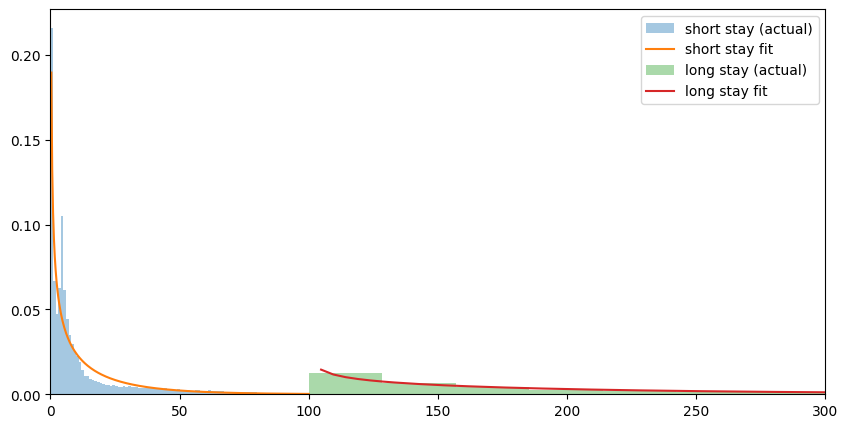

In [11]:
x_short = np.linspace(0, threshold, 300)
x_long = np.linspace(threshold, apt_data['los_days'].max(), 300)

plt.figure(figsize=(10,5))
plt.hist(short_stay_clean, bins=100, density=True, alpha=0.4, label='short stay (actual)')
plt.plot(x_short, stats.gamma.pdf(x_short, shape_short, loc=0, scale=scale_short), label='short stay fit')

plt.hist(long_stay, bins=50, density=True, alpha=0.4, label='long stay (actual)')
plt.plot(x_long, stats.gamma.pdf(x_long, shape_long, loc=threshold, scale=scale_long), label='long stay fit')

plt.xlim(0, 300)
plt.legend()
plt.show()

Mean daily intake: 45.42
Variance: 321.88
Variance/Mean ratio: 7.09


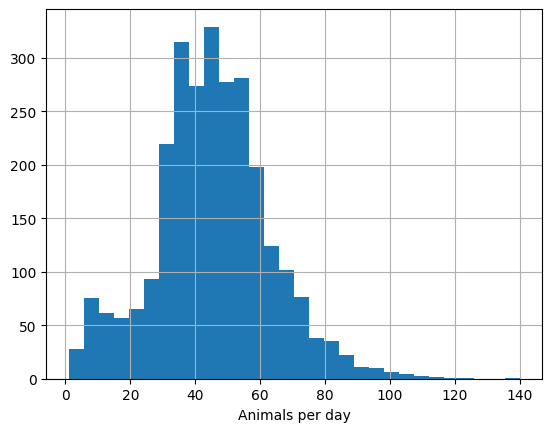

In [12]:
apt_data['intake_date'] = pd.to_datetime(apt_data['intake_time']).dt.date
daily_counts = apt_data.groupby('intake_date').size()

mean_intake = daily_counts.mean()
var_intake = daily_counts.var()

print(f"Mean daily intake: {mean_intake:.2f}")
print(f"Variance: {var_intake:.2f}")
print(f"Variance/Mean ratio: {var_intake/mean_intake:.2f}")

daily_counts.hist(bins=30)
plt.xlabel('Animals per day')
plt.show()

In [13]:
from scipy import stats

mean_intake = daily_counts.mean()
var_intake = daily_counts.var()

# Convert mean/variance to nbinom's n, p parameters
p_nb = mean_intake / var_intake
n_nb = mean_intake * p_nb / (1 - p_nb)

print(f"n={n_nb:.3f}, p={p_nb:.3f}")

n=7.462, p=0.141


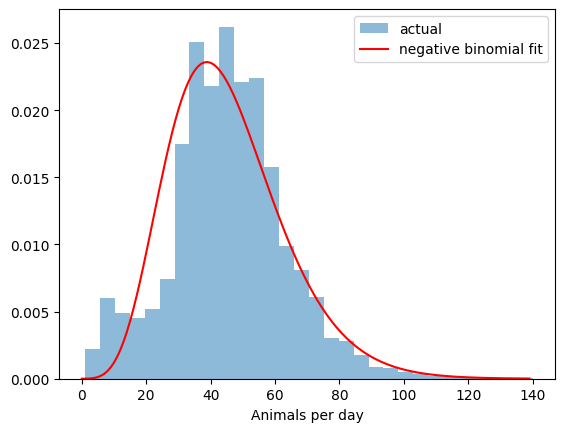

In [14]:
x = np.arange(0, daily_counts.max())
plt.hist(daily_counts, bins=30, density=True, alpha=0.5, label='actual')
plt.plot(x, stats.nbinom.pmf(x, n_nb, p_nb), 'r-', label='negative binomial fit')
plt.xlabel('Animals per day')
plt.legend()
plt.show()

In [15]:
print("=== Simulation Inputs ===")
print(f"p_long_stay: {p_long_stay:.4f}")
print(f"short_stay gamma: shape={shape_short:.3f}, scale={scale_short:.3f}")
print(f"long_stay gamma: shape={shape_long:.3f}, scale={scale_long:.3f}, threshold={threshold}")
print(f"daily_intake: n={n_nb:.3f}, p={p_nb:.3f} (negative binomial)")

=== Simulation Inputs ===
p_long_stay: 0.0319
short_stay gamma: shape=0.504, scale=25.278
long_stay gamma: shape=0.736, scale=126.786, threshold=100
daily_intake: n=7.462, p=0.141 (negative binomial)


In [16]:
import json

params = {
    "mean_intake": float(mean_intake),
    "p_long_stay": float(p_long_stay),
    "shape_short": float(shape_short),
    "scale_short": float(scale_short),
    "shape_long": float(shape_long),
    "scale_long": float(scale_long),
    "threshold": threshold,
    "n_nb": float(n_nb),
    "p_nb": float(p_nb),
}

with open('/kaggle/working/simulation_params.json', 'w') as f:
    json.dump(params, f, indent=2)